## 02 · Trade-offs, binding constraints, scenarios, robustness

### Analytical question
What does fairness cost, which constraint actually limits the business, and how does the allocation behave under stress?

### Evidence so far
Notebook 01: the MILP dominates greedy on this instance.

### Why this approach?
Instead of asserting weights, sweep the fairness weight and show the frontier; measure the marginal value of relaxing each constraint family; replay demand/capacity scenarios; perturb match quality to see how stable the allocation is.

,lambda_fairness,expected_purchases,providers_with_zero,gini_provider_load
0,0.0,279.374350,12,0.348373
1,0.1,279.147038,5,0.335037
2,0.3,278.626339,0,0.324429
3,0.6,278.626339,0,0.324429
4,1.0,278.626339,0,0.324429
5,2.0,278.626339,0,0.324429


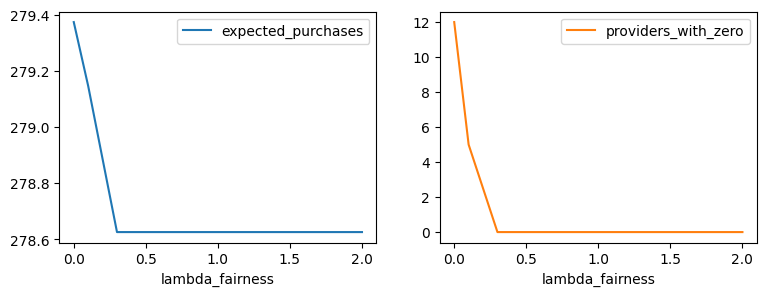

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))
os.chdir(os.path.abspath('../..'))
import pandas as pd, numpy as np, matplotlib.pyplot as plt
pd.set_option('display.width', 160)
%matplotlib inline
tr = pd.read_csv('outputs/project3/fairness_tradeoff.csv')
tr.plot(x='lambda_fairness', y=['expected_purchases','providers_with_zero'], subplots=True, layout=(1,2), figsize=(9,3)); tr[['lambda_fairness','expected_purchases','providers_with_zero','gini_provider_load']]

### Interpretation
Fairness is nearly free here: λ=0.3 removes all zero-lead providers at a cost of <0.5 expected purchases. That is the recommendation — and the chart is what makes it defensible.

In [2]:
pd.read_csv('outputs/project3/constraint_analysis.csv')

,relaxation,expected_purchases,gain,binding_share
0,none,278.626339,0.000000,0.727273
1,capacity +1 per provider,292.847014,14.220675,NaN
2,max offers per lead +1,327.322220,48.695880,NaN
3,priority min offers 2→1,278.626339,0.000000,NaN
4,ignore distance penalty,278.980844,0.354505,NaN


### Interpretation
The binding constraint is **offers per lead (M)**, then provider capacity; the priority minimum costs nothing. Raising M is a product decision with a revenue upside and a lead-quality downside (Project 2 shows providers already complain about wasted credits) — the optimiser quantifies one side of that trade.

In [3]:
pd.read_csv('outputs/project3/scenarios.csv')

,scenario,leads,capacity,status,milp_expected_purchases,greedy_expected_purchases,milp_leads_unfilled,greedy_leads_unfilled,milp_below_min,utilisation,share_capacity_binding
0,baseline,164,635,Optimal,278.626339,250.145542,0,4,0,0.766929,0.727273
1,demand_plus_10,180,635,Optimal,278.715273,250.321389,0,14,0,0.800000,0.772727
2,demand_plus_25,205,635,Optimal,301.611012,266.876913,0,19,0,0.877165,0.854545
3,capacity_minus_10,164,594,Optimal,275.544964,245.604221,0,5,0,0.814815,0.759091
4,capacity_minus_25,164,507,Optimal,260.981242,227.479780,0,7,0,0.921105,0.900000
5,max_distance_5km,164,635,Optimal,275.015228,250.145542,1,4,2,0.744882,0.690909
6,quiet_week,126,635,Optimal,220.270920,209.587032,0,2,0,0.577953,0.490909


In [4]:
pd.read_csv('outputs/project3/robustness.csv')

,sigma,assignment_jaccard,regret_pct
0,0.02,0.730695,0.390641
1,0.05,0.559078,2.328681
2,0.10,0.403165,7.540102


### Interpretation / Decision
Under demand +25% the optimiser still fills every lead where greedy leaves 18 unfilled. With noise on match quality the *specific* assignment changes a lot (Jaccard 0.4–0.75) but the regret is small (<3% at σ=0.05): many near-equivalent allocations exist, so the recommendation is robust in value even when it is not unique. Output = recommended allocation + reasons + unfilled list + scenario table (`outputs/project3/`).